In [1]:
source("~/bin/lit_utils.R")
lib_text()
lib_plot()
# 整合所有的元数据，加上ms2 count的数据
output_path <- "../results/S1/"
create_path(output_path)

In [2]:
# 函数
## 替换df的sample列中的-为_
reformat_s <- function(df){
  df$Sample %>% gsub("-","_",.) -> df$Sample
  return(df)
}

In [3]:
metadata_path="/rd1/user/lit/project/sORFs/raw_data/MS_metadata/MS_metadata_human_20250722.csv"
ms2_count_path="../results/S0/ms2_count.txt"

In [4]:
# 导入数据
fread(metadata_path,data.table = F,header = F) -> sample_metadata
fread(ms2_count_path,data.table = F) -> sample_ms2_count
colnames(sample_metadata) <- c("Sample","Eyzyme","Period","Enrichment")
reformat_s(sample_metadata) -> sample_metadata
colnames(sample_ms2_count) <- c("Sample","ms2_count")
reformat_s(sample_ms2_count) -> sample_ms2_count
# 添加replicate 列
sapply(str_split(sample_metadata$Sample, "_"), `[`, 2) -> replicates
sample_metadata$Replicate <- replicates
# 合并
merge(sample_metadata,sample_ms2_count) -> sample_metadata_1
# 导出
sample_metadata_1 %>% arrange(Enrichment) -> sample_metadata_ordered
head(sample_metadata_ordered)
table(sample_metadata$Eyzyme,sample_metadata$Enrichment)
fwrite_c(sample_metadata_ordered,o("sample_metadata_ordered.txt"))

,Sample,Eyzyme,Period,Enrichment,Replicate,ms2_count
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
1,21pcw_1_C8_LC_T,Trypsin_LysC,21pcw,C8,1,120313
2,21pcw_1_C8_LN_T,Trypsin_LysN,21pcw,C8,1,114757
3,21pcw_1_C8_T_AC,Trypsin_ArgC,21pcw,C8,1,120102
4,21pcw_1_C8_T_AN,Trypsin_AspN,21pcw,C8,1,116276
5,21pcw_1_C8_T_C,Trypsin_Chymotrypsin,21pcw,C8,1,102299
6,21pcw_1_C8_T_GC,Trypsin_GluC,21pcw,C8,1,111810


                      
                       C8 MWCO PAGE PCP
  Null                  0    3    0   0
  Trypsin               3    3    3   4
  Trypsin_ArgC          3    3    0   4
  Trypsin_AspN          3    3    0   4
  Trypsin_Chymotrypsin  3    3    3   4
  Trypsin_GluC          3    3    0   4
  Trypsin_LysC          3    3    0   4
  Trypsin_LysN          3    3    3   4

In [5]:
sample_metadata_1 %>% filter(Replicate!=4 & Eyzyme!="Null") -> sample_metadata_1


载入程辑包：‘scales’


The following object is masked from ‘package:tidyfst’:

    percent




[1] 9552825

[1] 132678.1

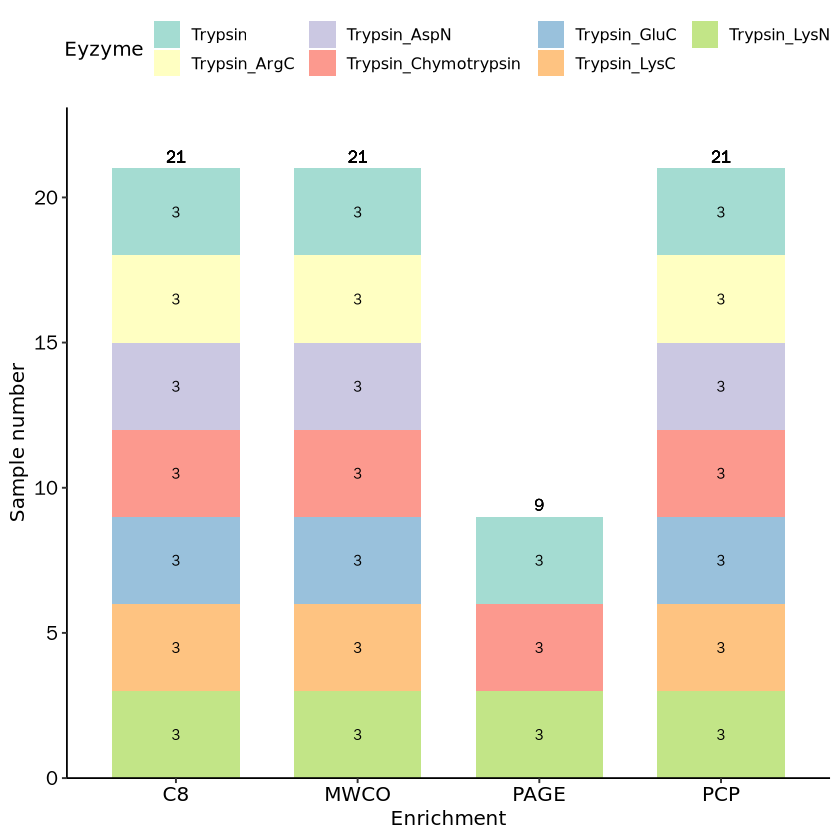

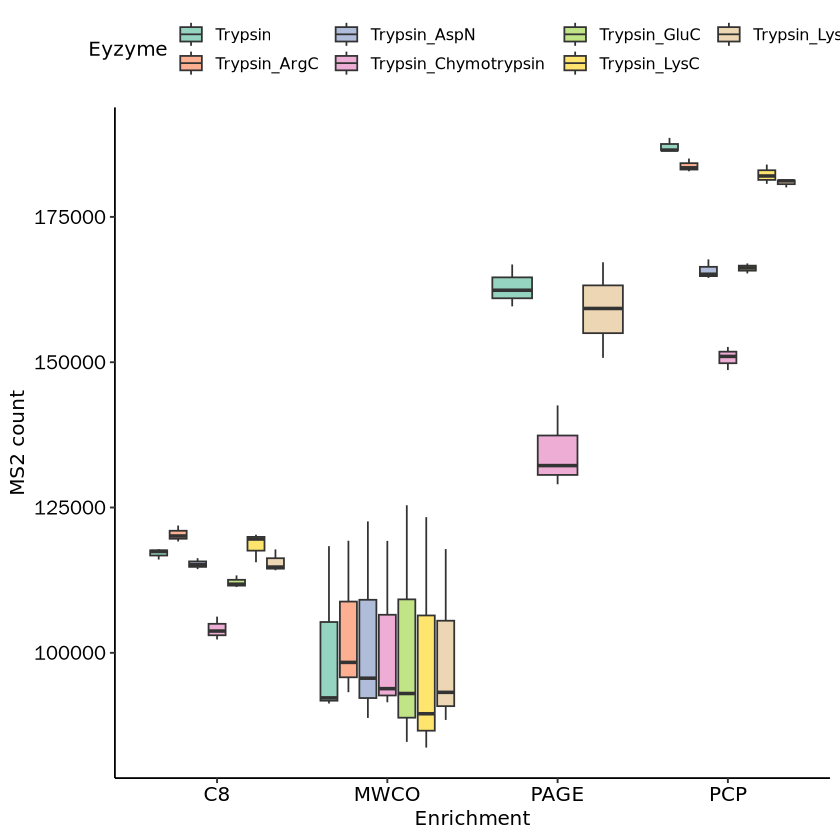

In [6]:
output_path <- "../figures/"
##### plot #####
##### 样本分布 #####
library(ggplot2)
library(dplyr)
library(scales)

# 计算每个组合的频数
count_data <- sample_metadata_1 %>% 
  group_by(Enrichment, Eyzyme) %>% 
  summarise(count = n(), .groups = 'drop')

# 创建堆叠柱状图
library(ggplot2)
library(dplyr)

# 计算频数数据（包含每个组合的计数和每列总数）
plot_data <- sample_metadata_1 %>% 
  group_by(Enrichment, Eyzyme) %>% 
  summarise(count = n(), .groups = 'drop') %>% 
  group_by(Enrichment) %>% 
  mutate(total = sum(count))  # 计算每个Enrichment的总数

# 创建堆叠柱状图
p <- ggplot(plot_data, aes(x = Enrichment, y = count, fill = Eyzyme)) +
  geom_col(position = "stack", width = 0.7, alpha = 0.8) +
  
  # 添加各部分的频数标签（显示在每个色块中间）
  geom_text(aes(label = ifelse(count > 0, count, "")),
            position = position_stack(vjust = 0.5),
            size = 3, color = "black") +
  
  # 添加总频数标签（显示在柱子顶部）
  geom_text(aes(x = Enrichment, y = total, label = total),
            inherit.aes = FALSE,  # 不继承前面的美学映射
            vjust = -0.5,         # 将标签放在柱子上方
            size = 3.5) +
  
  # 设置颜色和主题
  scale_fill_brewer(palette = "Set3") +
  theme_minimal() +
  labs(x = "Enrichment",
       y = "Sample number",
       fill = "Eyzyme") +
  
  # 调整y轴范围，给顶部标签留出空间
  scale_y_continuous(expand = expansion(mult = c(0, 0.1))) 

# 显示图形
p+theme_3() -> p_1
p_1

# 保存图形（可选）
ggsave(p_1,filename=o("enzyme_enrichment_distribution.pdf"),
       width = 8, height = 6, dpi = 300, bg = "white")

##### ms2count #####
# 10552762 接近1kw的原始谱图数量
sum(sample_metadata_1$ms2_count)
sum(sample_metadata_1$ms2_count)/72

library(ggplot2)
ggplot(sample_metadata_1, aes(x = Enrichment, y = ms2_count, fill = Eyzyme)) +
  geom_boxplot(position = position_dodge(0.8), width = 0.7, alpha = 0.7,outlier.shape = NA) +
  labs(x = "Enrichment",
       y = "MS2 count",
       fill = "Eyzyme") +
  theme_minimal() +
  scale_fill_brewer(palette = "Set2") -> p
p+theme_3() -> p_2
p_2
ggsave(p_2,filename=o("enzyme_enrichment_ms2_count.pdf"),
       width = 8, height = 6, dpi = 300, bg = "white")